# 실제 단락흔 이미지 로드 및 테스트

In [ ]:
import cv2
import numpy as np
import os
import time
import glob

def load_real_images(data_dir="Data"):
    """Data 폴더에서 실제 단락흔 이미지들을 로드"""
    # 노트북이 notebook/ 폴더에 있으므로 상위 폴더의 Data를 찾음
    # 여러 가능한 경로 시도
    possible_paths = [
        data_dir,  # 현재 디렉토리
        os.path.join("..", data_dir),  # 상위 디렉토리
        os.path.join(os.path.dirname(os.getcwd()), data_dir),  # 절대 경로
    ]
    
    # 실제 존재하는 경로 찾기
    actual_path = None
    for path in possible_paths:
        if os.path.exists(path) and os.path.isdir(path):
            actual_path = path
            break
    
    if actual_path is None:
        # 현재 작업 디렉토리 확인
        cwd = os.getcwd()
        print(f"⚠️ 현재 작업 디렉토리: {cwd}")
        # 프로젝트 루트 찾기 시도
        if "notebook" in cwd:
            # notebook 폴더에서 실행 중이면 상위로 이동
            project_root = os.path.dirname(cwd) if os.path.basename(cwd) == "notebook" else cwd
            actual_path = os.path.join(project_root, data_dir)
        else:
            actual_path = data_dir
    
    print(f"📂 [Data Loader] 경로 확인: {actual_path}")
    
    if not os.path.exists(actual_path):
        raise ValueError(f"Data 폴더를 찾을 수 없습니다. 시도한 경로: {actual_path}")
    
    image_files = sorted(glob.glob(os.path.join(actual_path, "*.png")))
    images = []
    
    print(f"📂 [Data Loader] {actual_path} 폴더에서 이미지 로드 중...")
    print(f"   발견된 이미지 파일: {len(image_files)}개")
    
    if len(image_files) == 0:
        print(f"   ⚠️ PNG 파일을 찾을 수 없습니다. 폴더 내용 확인:")
        try:
            files = os.listdir(actual_path)
            print(f"   폴더 내 파일들: {files[:10]}")  # 처음 10개만 출력
        except:
            pass
    
    for img_path in image_files:
        img = cv2.imread(img_path)
        if img is not None:
            images.append({
                'path': img_path,
                'filename': os.path.basename(img_path),
                'image': img,
                'shape': img.shape
            })
            print(f"   ✅ 로드 완료: {os.path.basename(img_path)} ({img.shape[1]}x{img.shape[0]})")
        else:
            print(f"   ❌ 로드 실패: {os.path.basename(img_path)}")
    
    return images

def load_single_image(image_path):
    """단일 이미지 로드"""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"이미지를 로드할 수 없습니다: {image_path}")
    return img

In [ ]:
def save_result(img, name, output_dir="outputs", quality=95):
    """
    결과 이미지를 파일로 저장
    
    Args:
        img: 저장할 이미지 (numpy array)
        name: 파일명
        output_dir: 출력 디렉토리
        quality: JPEG 품질 (0-100, 기본값: 95). PNG 파일인 경우 무시됨
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    path = os.path.join(output_dir, name)
    
    # 파일 확장자에 따라 저장 방식 결정
    ext = os.path.splitext(name)[1].lower()
    if ext in ['.jpg', '.jpeg']:
        # JPEG 저장 시 품질 지정
        cv2.imwrite(path, img, [cv2.IMWRITE_JPEG_QUALITY, quality])
    elif ext == '.png':
        # PNG 저장 시 압축 레벨 지정 (0-9, 기본값: 3)
        cv2.imwrite(path, img, [cv2.IMWRITE_PNG_COMPRESSION, 3])
    else:
        # 기타 형식은 기본 저장
        cv2.imwrite(path, img)
    
    print(f"   💾 저장 완료: {path}")

In [ ]:
# 실제 이미지 로드
# 노트북이 notebook/ 폴더에 있으므로 상위 폴더의 Data를 참조
real_images = load_real_images("../Data")

# 첫 번째 이미지를 테스트용으로 사용 (또는 특정 이미지 선택 가능)
if len(real_images) > 0:
    # 첫 번째 이미지 선택
    selected_image = real_images[0]
    input_img = selected_image['image']
    
    print(f"\n📸 선택된 이미지:")
    print(f"   - 파일명: {selected_image['filename']}")
    print(f"   - 크기: {input_img.shape[1]}x{input_img.shape[0]}")
    print(f"   - 경로: {selected_image['path']}")
    
    # 원본 이미지 저장
    save_result(input_img, f"0_input_{selected_image['filename']}")
else:
    print(f"\n⚠️ 로드된 이미지가 없습니다.")
    print(f"현재 작업 디렉토리: {os.getcwd()}")
    print(f"Data 폴더 경로 확인: {os.path.abspath('../Data')}")
    raise ValueError("로드된 이미지가 없습니다. Data 폴더를 확인해주세요.")

# Step 1 Cropper: 위치 탐지 및 크롭

In [ ]:
import cv2
import numpy as np

class ImageCropper:
    """
    [Morphological Gradient 기반 스마트 크롭퍼]
    GitHub의 Open CV 프로젝트들에서 객체 탐지용으로 가장 범용적으로 사용하는 방식입니다.
    
    핵심 원리:
    1. Morphological Gradient: 이미지의 밝기 변화량(엣지+질감)을 계산합니다.
       -> 단락흔의 '반짝임'과 '거친 표면'이 모두 높은 변화량을 가지므로 동시에 잡힙니다.
    2. Dilation (팽창): 흩어진 엣지들을 하나의 큰 덩어리로 뭉칩니다.
    3. Largest Contour: 가장 큰 덩어리를 찾아 크롭합니다.
    """
    def __init__(self):
        print(f"⚙️ [Cropper] Gradient 기반 심플 크롭퍼 초기화")

    def crop(self, img):
        try:
            # 1. 전처리: 그레이스케일 변환
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # 2. 형태학적 그래디언트 (Morphological Gradient) 계산
            # 밝은 곳과 어두운 곳의 차이를 극대화하여 '객체의 윤곽'을 추출
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
            gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
            
            # 3. 이진화 (Binarization)
            # Otsu 알고리즘으로 배경(낮은 변화)과 객체(높은 변화) 자동 분리
            _, binary = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            # 4. 팽창 (Dilation) - 중요!
            # 단락흔 내부의 기공이나 끊어진 부분을 메워서 하나의 큰 덩어리로 만듦
            # 커널 사이즈를 키우면(9x9) 더 넓게 뭉침
            expand_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
            closed = cv2.dilate(binary, expand_kernel, iterations=2)
            
            # 5. 가장 큰 덩어리(Contour) 찾기
            contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if not contours:
                print("⚠️ [Cropper] 탐지 실패. 중앙 크롭 수행.")
                return self._center_crop(img)

            # 면적 기준으로 정렬하여 가장 큰 놈 선택
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            
            # 6. 유효성 검사 (너무 작거나 전체를 다 덮으면 무시)
            img_h, img_w = img.shape[:2]
            if (w * h) < (img_w * img_h) * 0.01: # 1% 미만 잡티
                print("⚠️ [Cropper] 탐지된 영역이 너무 작음 (노이즈). 중앙 크롭 수행.")
                return self._center_crop(img)

            # 7. 패딩 추가 및 크롭
            pad = 40
            x1 = max(0, x - pad)
            y1 = max(0, y - pad)
            x2 = min(img_w, x + w + pad)
            y2 = min(img_h, y + h + pad)
            
            print(f"✅ [Cropper] 탐지 성공: ({x1}, {y1}) ~ ({x2}, {y2})")
            return img[y1:y2, x1:x2]

        except Exception as e:
            print(f"❌ [Cropper Error] {e}")
            return self._center_crop(img)

    def _center_crop(self, img):
        """탐지 실패 시 안전하게 중앙을 자르는 Fallback"""
        h, w = img.shape[:2]
        crop_size = min(h, w) // 2
        cx, cy = w // 2, h // 2
        
        x1 = max(0, cx - crop_size // 2)
        y1 = max(0, cy - crop_size // 2)
        x2 = min(w, cx + crop_size // 2)
        y2 = min(h, cy + crop_size // 2)
        
        return img[y1:y2, x1:x2]

In [ ]:
# ImageCropper 테스트
print("\n[1] ImageCropper 테스트")
print("=" * 60)

try:
    # 1. Cropper 초기화
    cropper = ImageCropper()
    
    # 2. 크롭 수행
    start_time = time.time()
    cropped_img = cropper.crop(input_img)
    elapsed_time = time.time() - start_time
    
    print(f"\n   ⏱️ 소요 시간: {elapsed_time:.4f}초")
    
    # 3. 결과 검증
    print(f"\n   📊 크롭 결과 검증:")
    print(f"   - 원본 이미지 크기: {input_img.shape}")
    print(f"   - 크롭된 이미지 크기: {cropped_img.shape}")
    
    # 크롭 비율 계산
    original_area = input_img.shape[0] * input_img.shape[1]
    cropped_area = cropped_img.shape[0] * cropped_img.shape[1]
    crop_ratio = (cropped_area / original_area) * 100
    print(f"   - 크롭 비율: {crop_ratio:.1f}%")
    
    # 크롭된 이미지 유효성 검사
    if cropped_img.size == 0:
        print("   ❌ 오류: 크롭된 이미지가 비어있습니다!")
    elif cropped_img.shape[0] == 0 or cropped_img.shape[1] == 0:
        print("   ❌ 오류: 크롭된 이미지의 크기가 0입니다!")
    elif cropped_img.shape[0] > input_img.shape[0] or cropped_img.shape[1] > input_img.shape[1]:
        print("   ⚠️ 경고: 크롭된 이미지가 원본보다 큽니다!")
    else:
        print("   ✅ 크롭 성공: 이미지가 정상적으로 크롭되었습니다.")
    
    # 4. 결과 저장 (PNG 무손실 압축)
    save_result(cropped_img, "1_cropped.png")
    
except Exception as e:
    print(f"   ❌ 실패: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
# ImageCropper 중간 처리 단계 시각화 (디버깅용)
print("\n[2] ImageCropper 처리 과정 시각화")
print("=" * 60)

try:
    # ImageCropper의 처리 과정을 단계별로 재현
    gray = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    
    # Morphological Gradient
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
    
    # 이진화
    _, binary = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 팽창
    expand_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    closed = cv2.dilate(binary, expand_kernel, iterations=2)
    
    # Contour 찾기
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Contour 시각화
    contour_img = input_img.copy()
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cv2.rectangle(contour_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.drawContours(contour_img, [largest_contour], -1, (255, 0, 0), 2)
        print(f"   📍 탐지된 영역: ({x}, {y}) 크기: {w}x{h}")
        print(f"   📦 Contour 개수: {len(contours)}")
    else:
        print(f"   ⚠️ Contour를 찾지 못했습니다.")
    
    # 시각화
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 원본 이미지
    axes[0, 0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('1. 원본 이미지', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # 그레이스케일
    axes[0, 1].imshow(gray, cmap='gray')
    axes[0, 1].set_title('2. 그레이스케일', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Morphological Gradient
    axes[0, 2].imshow(gradient, cmap='gray')
    axes[0, 2].set_title('3. Morphological Gradient', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    
    # 이진화
    axes[1, 0].imshow(binary, cmap='gray')
    axes[1, 0].set_title('4. 이진화 (Otsu)', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # 팽창 후
    axes[1, 1].imshow(closed, cmap='gray')
    axes[1, 1].set_title('5. 팽창 (Dilation)', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    # Contour 및 바운딩 박스
    axes[1, 2].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('6. 탐지된 영역 (초록: 바운딩박스, 파랑: Contour)', fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/cropper/cropper_process.png', dpi=150, bbox_inches='tight')
    print("   💾 처리 과정 이미지 저장 완료: outputs/cropper/cropper_process.png")
    plt.show()
    
except Exception as e:
    print(f"   ❌ 시각화 오류: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
# 원본 vs 크롭된 이미지 비교
print("\n[3] 원본 vs 크롭된 이미지 비교")
print("=" * 60)

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 원본 이미지
    axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'원본 이미지\n크기: {input_img.shape[1]}x{input_img.shape[0]}', 
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # 크롭된 이미지
    axes[1].imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'크롭된 이미지\n크기: {cropped_img.shape[1]}x{cropped_img.shape[0]}', 
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/cropper/crop_comparison.png', dpi=150, bbox_inches='tight')
    print("   💾 비교 이미지 저장 완료: outputs/cropper/crop_comparison.png")
    plt.show()
    
    # 통계 정보 출력
    print(f"\n   📊 통계 정보:")
    print(f"   - 원본 면적: {input_img.shape[0] * input_img.shape[1]:,} 픽셀")
    print(f"   - 크롭 면적: {cropped_img.shape[0] * cropped_img.shape[1]:,} 픽셀")
    print(f"   - 면적 감소율: {(1 - cropped_area/original_area)*100:.1f}%")
    
except Exception as e:
    print(f"   ❌ 비교 오류: {e}")
    import traceback
    traceback.print_exc()


# Step 2-1 ImageEnhancer

In [ ]:
import os
import cv2
import torch
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer

class ImageEnhancer:
    def __init__(self, model_path="weights/RealESRGAN_x4plus.pth"):
        self.upscaler = self._load_model(model_path)

    def _load_model(self, model_path):
        if not os.path.exists(os.path.dirname(model_path)):
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
        if not os.path.exists(model_path):
            print(f"   📥 모델 다운로드 중...")
            url = 'https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth'
            torch.hub.download_url_to_file(url, model_path)

        model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        return RealESRGANer(scale=4, model_path=model_path, model=model, tile=0, pre_pad=0, half=(device.type=='cuda'), device=device)

    def upscale(self, img):
        try:
            output, _ = self.upscaler.enhance(img, outscale=4)
            return output
        except Exception as e:
            print(f"   ⚠️ Upscale Error: {e}")
            h, w = img.shape[:2]
            return cv2.resize(img, (w*4, h*4))

In [ ]:
# ImageEnhancer 테스트
print("\n[1] ImageEnhancer 테스트")
print("=" * 60)

try:
    # 1. Enhancer 초기화
    enhancer = ImageEnhancer() # 모델 로드 (최초 실행시 다운로드)
    
    # 2. 향상 수행
    start_time = time.time()
    enhanced_img = enhancer.upscale(cropped_img)
    elapsed_time = time.time() - start_time
    
    print(f"\n   ⏱️ 소요 시간: {elapsed_time:.4f}초")
    
    # 3. 결과 검증
    print(f"\n   📊 향상 결과 검증:")
    print(f"   - 입력 이미지 크기: {cropped_img.shape}")
    print(f"   - 향상된 이미지 크기: {enhanced_img.shape}")
    
    # 크기 비율 확인 (4배 확대 여부)
    scale_h = enhanced_img.shape[0] / cropped_img.shape[0]
    scale_w = enhanced_img.shape[1] / cropped_img.shape[1]
    print(f"   - 높이 확대 비율: {scale_h:.2f}x")
    print(f"   - 너비 확대 비율: {scale_w:.2f}x")
    
    # 예상 크기와 실제 크기 비교
    expected_h = cropped_img.shape[0] * 4
    expected_w = cropped_img.shape[1] * 4
    print(f"   - 예상 크기: {expected_h}x{expected_w}")
    print(f"   - 실제 크기: {enhanced_img.shape[0]}x{enhanced_img.shape[1]}")
    
    # 향상된 이미지 유효성 검사
    if enhanced_img.size == 0:
        print("   ❌ 오류: 향상된 이미지가 비어있습니다!")
    elif enhanced_img.shape[0] == 0 or enhanced_img.shape[1] == 0:
        print("   ❌ 오류: 향상된 이미지의 크기가 0입니다!")
    elif abs(scale_h - 4.0) > 0.1 or abs(scale_w - 4.0) > 0.1:
        print(f"   ⚠️ 경고: 예상된 4배 확대와 다릅니다 (높이: {scale_h:.2f}x, 너비: {scale_w:.2f}x)")
    else:
        print("   ✅ 향상 성공: 이미지가 정상적으로 4배 확대되었습니다.")
    
    # 픽셀 값 범위 확인
    min_val = enhanced_img.min()
    max_val = enhanced_img.max()
    print(f"   - 픽셀 값 범위: {min_val} ~ {max_val}")
    
    # 면적 증가율
    input_area = cropped_img.shape[0] * cropped_img.shape[1]
    enhanced_area = enhanced_img.shape[0] * enhanced_img.shape[1]
    area_increase = (enhanced_area / input_area) * 100
    print(f"   - 면적 증가율: {area_increase:.1f}% (예상: 1600%)")
    
    # 4. 결과 저장 (PNG 무손실 압축)
    save_result(enhanced_img, "2_enhanced.png")
    
except Exception as e:
    print(f"   ❌ 실패: {e}")
    import traceback
    traceback.print_exc()
    enhanced_img = cropped_img # 실패 시 원본 사용

In [ ]:
# 향상 결과 시각화 비교
print("\n[2] 향상 결과 시각화")
print("=" * 60)

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 크롭된 이미지 (원본)
    axes[0].imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'크롭된 이미지 (원본)\n크기: {cropped_img.shape[1]}x{cropped_img.shape[0]}', 
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # 향상된 이미지
    axes[1].imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'향상된 이미지 (4x 확대)\n크기: {enhanced_img.shape[1]}x{enhanced_img.shape[0]}', 
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/enhancer/enhancement_comparison.png', dpi=150, bbox_inches='tight')
    print("   💾 비교 이미지 저장 완료: outputs/enhancer/enhancement_comparison.png")
    plt.show()
    
    # 저장된 파일 확인
    enhanced_path = 'outputs/2_enhanced.png'
    if os.path.exists(enhanced_path):
        file_size = os.path.getsize(enhanced_path) / 1024  # KB
        print(f"\n   📁 저장된 파일 정보:")
        print(f"   - 파일 경로: {enhanced_path}")
        print(f"   - 파일 크기: {file_size:.2f} KB")
        print(f"   ✅ 파일이 정상적으로 저장되었습니다.")
    else:
        print(f"   ⚠️ 경고: 파일이 저장되지 않았습니다.")
        
except Exception as e:
    print(f"   ❌ 시각화 오류: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
# 저장된 향상 이미지 파일 검증
print("\n[3] 저장된 파일 검증")
print("=" * 60)

try:
    enhanced_path = 'outputs/2_enhanced.png'
    
    if os.path.exists(enhanced_path):
        # 저장된 파일 읽기
        loaded_img = cv2.imread(enhanced_path)
        
        if loaded_img is not None:
            print(f"   ✅ 파일 읽기 성공")
            print(f"   - 파일 경로: {enhanced_path}")
            print(f"   - 로드된 이미지 크기: {loaded_img.shape}")
            print(f"   - 파일 크기: {os.path.getsize(enhanced_path) / 1024:.2f} KB")
            
            # 메모리의 이미지와 저장된 이미지 비교
            if loaded_img.shape == enhanced_img.shape:
                print(f"   ✅ 메모리와 파일의 이미지 크기가 일치합니다.")
            else:
                print(f"   ⚠️ 경고: 메모리 이미지({enhanced_img.shape})와 파일 이미지({loaded_img.shape}) 크기가 다릅니다.")
            
            # 픽셀 값 비교 (PNG는 무손실 압축이므로 차이가 거의 없어야 함)
            sample_diff = np.abs(loaded_img.astype(float) - enhanced_img.astype(float)).max()
            if sample_diff < 1.0:  # PNG는 무손실이므로 차이가 거의 없어야 함
                print(f"   ✅ 이미지 데이터가 정상적으로 저장되었습니다 (최대 차이: {sample_diff:.2f})")
            elif sample_diff < 5.0:
                print(f"   ⚠️ 경고: 미세한 차이가 있습니다 (최대 차이: {sample_diff:.2f}) - PNG는 무손실이므로 이상적이지 않습니다")
            else:
                print(f"   ❌ 오류: 이미지 데이터에 큰 차이가 있습니다 (최대 차이: {sample_diff:.2f}) - PNG 저장에 문제가 있을 수 있습니다")
                
            # 이미지 품질 확인
            print(f"\n   📊 이미지 품질 정보:")
            print(f"   - 평균 밝기: {loaded_img.mean():.2f}")
            print(f"   - 표준 편차: {loaded_img.std():.2f}")
            
        else:
            print(f"   ❌ 오류: 파일을 읽을 수 없습니다.")
    else:
        print(f"   ❌ 오류: 파일이 존재하지 않습니다.")
        
except Exception as e:
    print(f"   ❌ 검증 오류: {e}")
    import traceback
    traceback.print_exc()


# Step 2-2 Filter

In [ ]:
import cv2

class TextureFilter:
    @staticmethod
    def apply_clahe(img):
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

In [ ]:
# TextureFilter 테스트 (Enhancer 이후, 순차 처리)
print("\n[2-2] TextureFilter (CLAHE) 테스트")
print("=" * 60)

try:
    # TextureFilter는 enhanced_img를 입력으로 받음 (Enhancer 이후 순차 처리)
    print("\n   📝 입력: 향상된 이미지 (Enhancer 4x 확대 후)")
    print(f"   - 입력 이미지 크기: {enhanced_img.shape}")
    
    # CLAHE 필터 적용
    start_time = time.time()
    filtered_img = TextureFilter.apply_clahe(enhanced_img)
    elapsed_time = time.time() - start_time
    
    print(f"\n   ⏱️ 소요 시간: {elapsed_time:.4f}초")
    
    # 결과 검증
    print(f"\n   📊 필터 결과 검증:")
    print(f"   - 입력 이미지 크기: {enhanced_img.shape}")
    print(f"   - 필터 적용 후 크기: {filtered_img.shape}")
    
    # 크기 확인 (크기는 변경되지 않아야 함)
    if filtered_img.shape == enhanced_img.shape:
        print("   ✅ 크기 일치: 필터 적용 후 이미지 크기가 유지되었습니다.")
    else:
        print(f"   ⚠️ 경고: 이미지 크기가 변경되었습니다!")
    
    # 픽셀 값 범위 확인
    print(f"\n   📊 픽셀 값 통계:")
    print(f"   - 입력 이미지 픽셀 범위: {enhanced_img.min()} ~ {enhanced_img.max()}")
    print(f"   - 필터 적용 후 픽셀 범위: {filtered_img.min()} ~ {filtered_img.max()}")
    print(f"   - 입력 이미지 평균 밝기: {enhanced_img.mean():.2f}")
    print(f"   - 필터 적용 후 평균 밝기: {filtered_img.mean():.2f}")
    print(f"   - 입력 이미지 표준 편차: {enhanced_img.std():.2f}")
    print(f"   - 필터 적용 후 표준 편차: {filtered_img.std():.2f}")
    
    # 이미지 변화량 확인
    diff = np.abs(filtered_img.astype(float) - enhanced_img.astype(float))
    print(f"\n   📈 변화량 분석:")
    print(f"   - 평균 변화량: {diff.mean():.2f}")
    print(f"   - 최대 변화량: {diff.max():.2f}")
    print(f"   - 변화된 픽셀 비율: {(diff > 1.0).sum() / diff.size * 100:.1f}%")
    
    # 결과 저장 (PNG 무손실 압축)
    save_result(filtered_img, "3_filtered.png")
    
    print("\n   ✅ 필터 적용 성공!")
    
except Exception as e:
    print(f"   ❌ 실패: {e}")
    import traceback
    traceback.print_exc()
    filtered_img = enhanced_img  # 실패 시 향상된 이미지 사용

In [ ]:
# TextureFilter 결과 시각화 비교
print("\n[2-3] TextureFilter 결과 시각화")
print("=" * 60)

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 향상된 이미지 (Enhancer 결과)
    axes[0].imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Enhancer 결과 (4x 확대)\n크기: {enhanced_img.shape[1]}x{enhanced_img.shape[0]}', 
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # 필터 적용된 이미지 (최종 결과)
    axes[1].imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Filter 적용 (CLAHE)\n크기: {filtered_img.shape[1]}x{filtered_img.shape[0]}', 
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/filter/filter_comparison.png', dpi=150, bbox_inches='tight')
    print("   💾 비교 이미지 저장 완료: outputs/filter/filter_comparison.png")
    plt.show()
    
except Exception as e:
    print(f"   ❌ 시각화 오류: {e}")
    import traceback
    traceback.print_exc()


# Step 2-3 Metrics

In [20]:
import cv2
import numpy as np
from skimage import measure

class MorphologyAnalyzer:
    def analyze(self, img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        label_img = measure.label(binary)
        regions = measure.regionprops(label_img)
        
        metrics = {"circularity": 0.0, "solidity": 0.0, "area": 0}
        
        if regions:
            largest = max(regions, key=lambda r: r.area)
            perimeter = largest.perimeter if largest.perimeter > 0 else 1
            metrics["circularity"] = round((4 * np.pi * largest.area) / (perimeter**2), 3)
            metrics["solidity"] = round(largest.solidity, 3)
            metrics["area"] = largest.area
            
        return metrics, binary

In [ ]:
# MorphologyAnalyzer 테스트 (Enhance 이후 데이터 처리)
print("\n[3] MorphologyAnalyzer 테스트")
print("=" * 60)

try:
    # Enhancer 결과가 있는지 확인
    try:
        enhanced_img
    except NameError:
        print("   ⚠️ Enhancer 결과가 없습니다. Enhancer 테스트를 먼저 실행해주세요.")
        raise

    # 1. Analyzer 초기화
    analyzer = MorphologyAnalyzer()

    # 2. 분석 수행 (Enhance 이후 데이터 처리)
    print("\n   📝 입력: Enhancer 적용된 이미지")
    print(f"   - 입력 이미지 크기: {enhanced_img.shape}")

    start_time = time.time()
    metrics, binary_mask = analyzer.analyze(enhanced_img)
    elapsed_time = time.time() - start_time

    print(f"\n   ⏱️ 소요 시간: {elapsed_time:.4f}초")

    # 3. 분석 결과 검증
    print(f"\n   📊 형태학적 분석 결과:")
    print(f"   - Circularity (원형도): {metrics['circularity']}")
    print(f"     * 1.0에 가까울수록 완전한 원형")
    print(f"     * 0.0에 가까울수록 불규칙한 형태")
    print(f"   - Solidity (고형도): {metrics['solidity']}")
    print(f"     * 1.0에 가까울수록 내부가 채워진 형태")
    print(f"     * 0.0에 가까울수록 내부가 비어있거나 요철이 많음")
    print(f"   - Area (면적): {metrics['area']:,} 픽셀")

    # 이미지 크기 대비 면적 비율
    total_pixels = enhanced_img.shape[0] * enhanced_img.shape[1]
    area_ratio = (metrics['area'] / total_pixels) * 100
    print(f"   - 면적 비율: {area_ratio:.2f}% (전체 이미지 대비)")
    
    # 결과 해석
    print(f"\n   📈 결과 해석:")
    if metrics['circularity'] > 0.7:
        print(f"   ✅ 원형도 높음: 단락흔이 비교적 원형에 가까운 형태")
    elif metrics['circularity'] > 0.4:
        print(f"   ⚠️ 원형도 중간: 단락흔이 중간 정도의 원형도")
    else:
        print(f"   ⚠️ 원형도 낮음: 단락흔이 불규칙한 형태")
    
    if metrics['solidity'] > 0.8:
        print(f"   ✅ 고형도 높음: 단락흔 내부가 비교적 채워진 형태")
    elif metrics['solidity'] > 0.5:
        print(f"   ⚠️ 고형도 중간: 단락흔 내부에 일부 공간이 있음")
    else:
        print(f"   ⚠️ 고형도 낮음: 단락흔 내부에 많은 공간이나 요철이 있음")
    
    # 4. 이진 마스크 저장 (PNG 무손실 압축)
    save_result(binary_mask, "4_analysis_mask.png", "outputs/analyzer")
    
    print("\n   ✅ 형태학적 분석 완료!")
    
except Exception as e:
    print(f"   ❌ 실패: {e}")
    import traceback
    traceback.print_exc()



[3] MorphologyAnalyzer 테스트

   📝 입력: Filter 적용된 이미지
   - 입력 이미지 크기: (532, 904, 3)

   ⏱️ 소요 시간: 0.4021초

   📊 형태학적 분석 결과:
   - Circularity (원형도): 0.115
     * 1.0에 가까울수록 완전한 원형
     * 0.0에 가까울수록 불규칙한 형태
   - Solidity (고형도): 0.706
     * 1.0에 가까울수록 내부가 채워진 형태
     * 0.0에 가까울수록 내부가 비어있거나 요철이 많음
   - Area (면적): 339,401.0 픽셀
   - 면적 비율: 70.57% (전체 이미지 대비)

   📈 결과 해석:
   ⚠️ 원형도 낮음: 단락흔이 불규칙한 형태
   ⚠️ 고형도 중간: 단락흔 내부에 일부 공간이 있음
   💾 저장 완료: outputs/analyzer\4_analysis_mask.png

   ✅ 형태학적 분석 완료!



[3-2] MorphologyAnalyzer 결과 시각화


C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\1892192474.py:42: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\1892192474.py:42: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\1892192474.py:42: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\1892192474.py:42: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\1892192474.py:42: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\1892192474.py:42: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from 

   💾 분석 결과 이미지 저장 완료: outputs/analyzer/morphology_analysis.png


c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.p

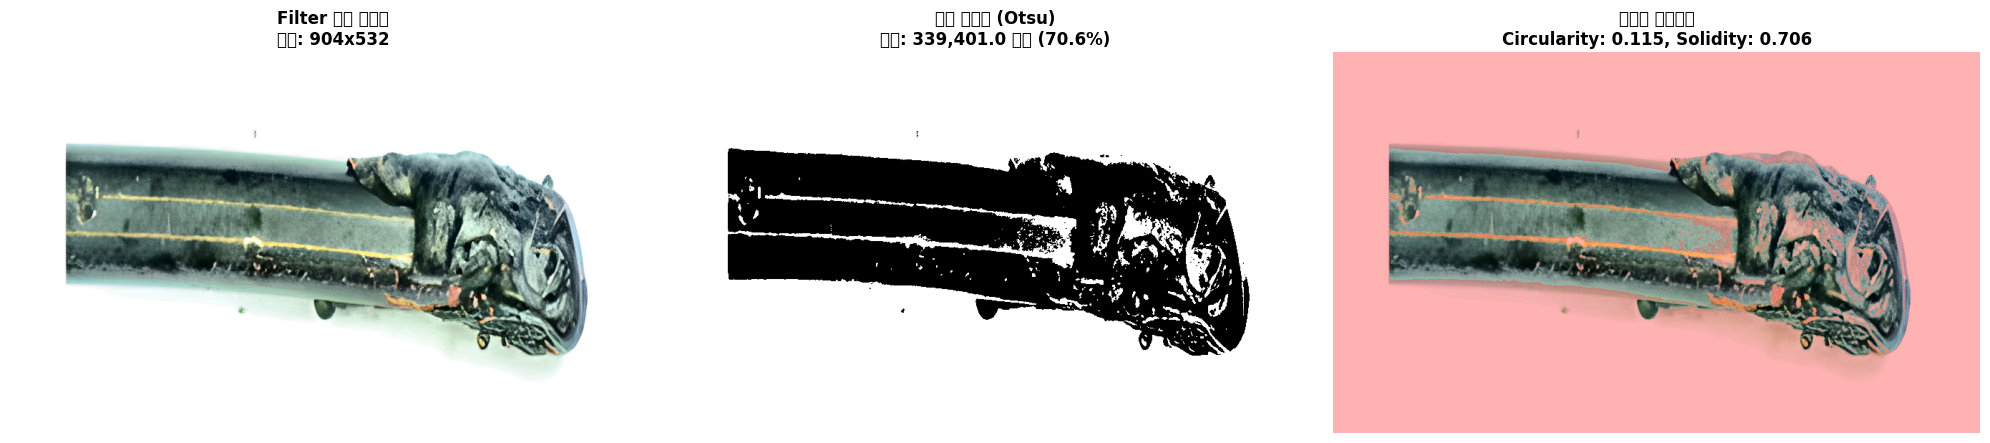

In [ ]:
# MorphologyAnalyzer 결과 시각화
print("\n[3-2] MorphologyAnalyzer 결과 시각화")
print("=" * 60)

try:
    import matplotlib.pyplot as plt
    
    # 분석 결과가 있는지 확인
    try:
        metrics
        binary_mask
    except NameError:
        print("   ⚠️ 분석 결과가 없습니다. MorphologyAnalyzer 테스트를 먼저 실행해주세요.")
        raise
    
    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
        # Enhancer 적용된 이미지 (원본)
    axes[0].imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Enhancer 적용 이미지\n크기: {enhanced_img.shape[1]}x{enhanced_img.shape[0]}', 
                     fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # 이진 마스크
    axes[1].imshow(binary_mask, cmap='gray')
    axes[1].set_title(f'이진 마스크 (Otsu)\n면적: {metrics["area"]:,} 픽셀 ({metrics["area"]/(enhanced_img.shape[0]*enhanced_img.shape[1])*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # 마스크 오버레이
    overlay = enhanced_img.copy()
    # 마스크 영역을 빨간색으로 표시
    overlay[binary_mask == 255] = [0, 0, 255]  # BGR에서 빨간색
    blended = cv2.addWeighted(enhanced_img, 0.7, overlay, 0.3, 0)
    
    axes[2].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'마스크 오버레이\nCircularity: {metrics["circularity"]}, Solidity: {metrics["solidity"]}', 
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/analyzer/morphology_analysis.png', dpi=150, bbox_inches='tight')
    print("   💾 분석 결과 이미지 저장 완료: outputs/analyzer/morphology_analysis.png")
    plt.show()
    
except Exception as e:
    print(f"   ❌ 시각화 오류: {e}")
    import traceback
    traceback.print_exc()


In [23]:
# MorphologyAnalyzer 상세 분석 및 통계
print("\n[3-3] MorphologyAnalyzer 상세 분석")
print("=" * 60)

try:
    from skimage import measure
    
    # 이진 마스크에서 추가 정보 추출
    label_img = measure.label(binary_mask)
    regions = measure.regionprops(label_img)
    
    if regions:
        largest_region = max(regions, key=lambda r: r.area)
        
        print(f"\n   📊 가장 큰 영역 상세 정보:")
        print(f"   - 면적: {largest_region.area:,} 픽셀")
        print(f"   - 둘레: {largest_region.perimeter:.2f} 픽셀")
        print(f"   - 중심 좌표: ({largest_region.centroid[0]:.2f}, {largest_region.centroid[1]:.2f})")
        print(f"   - 바운딩 박스: {largest_region.bbox}")
        
        # 종횡비 계산
        bbox = largest_region.bbox
        width = bbox[3] - bbox[1]
        height = bbox[2] - bbox[0]
        aspect_ratio = width / height if height > 0 else 0
        print(f"   - 종횡비: {aspect_ratio:.2f} (가로/세로)")
        
        # 등가 직경 (Equivalent Diameter)
        equivalent_diameter = largest_region.equivalent_diameter
        print(f"   - 등가 직경: {equivalent_diameter:.2f} 픽셀")
        
        # 방향 (Orientation)
        orientation = largest_region.orientation
        print(f"   - 방향: {np.degrees(orientation):.2f}도")
        
        # 전체 영역 개수
        print(f"\n   📦 영역 통계:")
        print(f"   - 총 영역 개수: {len(regions)}개")
        
        # 면적별 정렬
        areas = sorted([r.area for r in regions], reverse=True)
        print(f"   - 가장 큰 영역: {areas[0]:,} 픽셀")
        if len(areas) > 1:
            print(f"   - 두 번째 영역: {areas[1]:,} 픽셀")
        if len(areas) > 2:
            print(f"   - 세 번째 영역: {areas[2]:,} 픽셀")
        
        # 면적 분포
        total_area = sum(areas)
        print(f"\n   📈 면적 분포:")
        print(f"   - 가장 큰 영역 비율: {(areas[0]/total_area)*100:.1f}%")
        if len(areas) > 1:
            print(f"   - 상위 3개 영역 합계: {sum(areas[:3]):,} 픽셀 ({(sum(areas[:3])/total_area)*100:.1f}%)")
        
    else:
        print("   ⚠️ 분석된 영역이 없습니다.")
    
except Exception as e:
    print(f"   ❌ 상세 분석 오류: {e}")
    import traceback
    traceback.print_exc()



[3-3] MorphologyAnalyzer 상세 분석

   📊 가장 큰 영역 상세 정보:
   - 면적: 339,401.0 픽셀
   - 둘레: 6102.35 픽셀
   - 중심 좌표: (269.14, 449.13)
   - 바운딩 박스: (0, 0, 532, 904)
   - 종횡비: 1.70 (가로/세로)
   - 등가 직경: 657.37 픽셀
   - 방향: -87.49도

   📦 영역 통계:
   - 총 영역 개수: 283개
   - 가장 큰 영역: 339,401.0 픽셀
   - 두 번째 영역: 5,480.0 픽셀
   - 세 번째 영역: 2,100.0 픽셀

   📈 면적 분포:
   - 가장 큰 영역 비율: 95.6%
   - 상위 3개 영역 합계: 346,981.0 픽셀 (97.7%)



[4] 전체 파이프라인 시각화


C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\181678945.py:68: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\181678945.py:68: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\181678945.py:68: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\181678945.py:68: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\181678945.py:68: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_13660\181678945.py:68: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s)

   💾 전체 파이프라인 이미지 저장 완료: outputs/full_pipeline.png


c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47213 (\N{HANGUL SYLLABLE ROB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtool

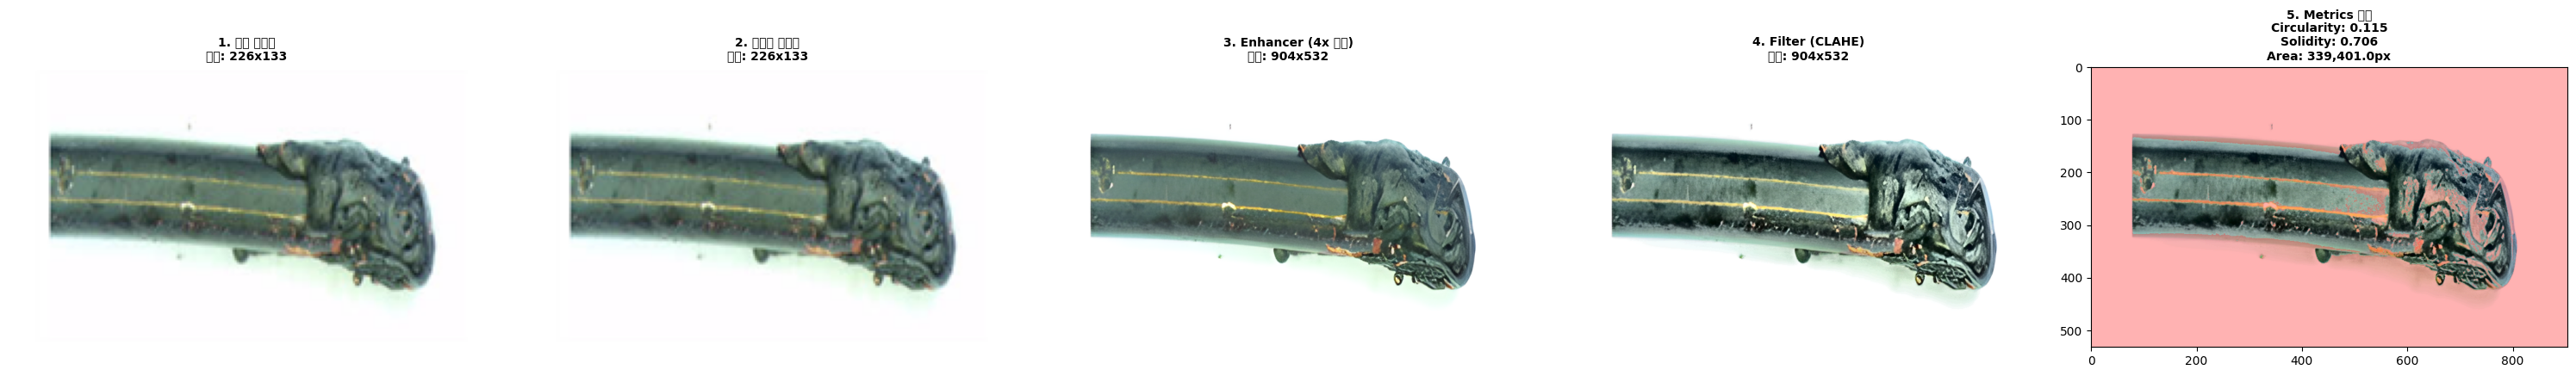


   📊 전체 파이프라인 통계 요약:
   - 원본 크기: 226x133 (30,058 픽셀)
   - 크롭 크기: 226x133 (30,058 픽셀)
   - Enhancer 크기: 904x532 (480,928 픽셀)
   - Filter 크기: 904x532 (480,928 픽셀)

   📈 처리 비율:
   - 크롭 비율: 100.0%
   - Enhancer 배율: 4.0x
   - Filter 배율: 1.0x (크기 유지)

   📊 Metrics 분석 결과:
   - Circularity (원형도): 0.115
   - Solidity (고형도): 0.706
   - Area (면적): 339,401.0 픽셀
   - 면적 비율: 70.57% (전체 이미지 대비)

   🔄 순차 처리 구조:
   원본 → 크롭 → Enhancer (4x 확대) → Filter (CLAHE) → Metrics 분석
                        ↓                    ↓              ↓
                  향상된 이미지        필터링된 이미지    분석 결과


In [ ]:
# 전체 파이프라인 시각화 (원본 -> 크롭 -> Enhancer -> Filter -> Metrics 순차 처리)
print("\n[4] 전체 파이프라인 시각화")
print("=" * 60)

try:
    import matplotlib.pyplot as plt
    
    # Filter가 정의되어 있는지 확인
    try:
        filtered_img
    except NameError:
        print("   ⚠️ Filter 결과가 없습니다. Filter 테스트를 먼저 실행해주세요.")
        filtered_img = enhanced_img  # 기본값으로 향상된 이미지 사용
    
    # Metrics 분석 결과가 있는지 확인
    has_metrics = False
    try:
        metrics
        binary_mask
        has_metrics = True
    except NameError:
        print("   ⚠️ Metrics 분석 결과가 없습니다. MorphologyAnalyzer 테스트를 먼저 실행해주세요.")
    
    # Metrics 마스크 오버레이 생성
    if has_metrics:
        overlay = enhanced_img.copy()
        overlay[binary_mask == 255] = [0, 0, 255]  # BGR에서 빨간색
        metrics_overlay = cv2.addWeighted(enhanced_img, 0.7, overlay, 0.3, 0)
    
    # 1x5 레이아웃으로 순차 처리 구조 시각화 (Metrics 포함)
    fig, axes = plt.subplots(1, 5, figsize=(30, 6))
    
    # 원본 이미지
    axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'1. 원본 이미지\n크기: {input_img.shape[1]}x{input_img.shape[0]}', 
                     fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # 크롭된 이미지
    axes[1].imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'2. 크롭된 이미지\n크기: {cropped_img.shape[1]}x{cropped_img.shape[0]}', 
                     fontsize=10, fontweight='bold')
    axes[1].axis('off')
    
    # Enhancer 결과
    axes[2].imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'3. Enhancer (4x 확대)\n크기: {enhanced_img.shape[1]}x{enhanced_img.shape[0]}', 
                     fontsize=10, fontweight='bold')
    axes[2].axis('off')
    
    # Filter 결과
    axes[3].imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f'4. Filter (CLAHE)\n크기: {filtered_img.shape[1]}x{filtered_img.shape[0]}', 
                     fontsize=10, fontweight='bold')
    axes[3].axis('off')
    
    # Metrics 분석 결과 (마스크 오버레이)
    if has_metrics:
        axes[4].imshow(cv2.cvtColor(metrics_overlay, cv2.COLOR_BGR2RGB))
        axes[4].set_title(f'5. Metrics 분석\nCircularity: {metrics["circularity"]}\nSolidity: {metrics["solidity"]}\nArea: {metrics["area"]:,}px', 
                         fontsize=10, fontweight='bold')
    else:
        axes[4].text(0.5, 0.5, 'Metrics\n분석 필요', 
                     ha='center', va='center', fontsize=12, 
                     transform=axes[4].transAxes)
        axes[4].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/full_pipeline.png', dpi=150, bbox_inches='tight')
    print("   💾 전체 파이프라인 이미지 저장 완료: outputs/full_pipeline.png")
    plt.show()
    
    # 전체 통계 요약
    print(f"\n   📊 전체 파이프라인 통계 요약:")
    print(f"   - 원본 크기: {input_img.shape[1]}x{input_img.shape[0]} ({input_img.shape[0]*input_img.shape[1]:,} 픽셀)")
    print(f"   - 크롭 크기: {cropped_img.shape[1]}x{cropped_img.shape[0]} ({cropped_img.shape[0]*cropped_img.shape[1]:,} 픽셀)")
    print(f"   - Enhancer 크기: {enhanced_img.shape[1]}x{enhanced_img.shape[0]} ({enhanced_img.shape[0]*enhanced_img.shape[1]:,} 픽셀)")
    print(f"   - Filter 크기: {filtered_img.shape[1]}x{filtered_img.shape[0]} ({filtered_img.shape[0]*filtered_img.shape[1]:,} 픽셀)")
    print(f"\n   📈 처리 비율:")
    print(f"   - 크롭 비율: {(cropped_img.shape[0]*cropped_img.shape[1] / (input_img.shape[0]*input_img.shape[1]))*100:.1f}%")
    print(f"   - Enhancer 배율: {enhanced_img.shape[0]/cropped_img.shape[0]:.1f}x")
    print(f"   - Filter 배율: {filtered_img.shape[0]/enhanced_img.shape[0]:.1f}x (크기 유지)")
    
    # Metrics 분석 결과 요약
    if has_metrics:
        print(f"\n   📊 Metrics 분석 결과:")
        print(f"   - Circularity (원형도): {metrics['circularity']}")
        print(f"   - Solidity (고형도): {metrics['solidity']}")
        print(f"   - Area (면적): {metrics['area']:,} 픽셀")
        total_pixels = enhanced_img.shape[0] * enhanced_img.shape[1]
        area_ratio = (metrics['area'] / total_pixels) * 100
        print(f"   - 면적 비율: {area_ratio:.2f}% (전체 이미지 대비)")
    
        # 순차 처리 구조 설명
    print(f"\n   🔄 순차 처리 구조:")
    print(f"   원본 → 크롭 → Enhancer (4x 확대) → Filter (CLAHE) → Metrics 분석 (Enhancer 기반)")                                                                               
    print(f"                        ↓                    ↓                    ↓")     
    print(f"                  향상된 이미지        필터링된 이미지    분석 결과")
    
except Exception as e:
    print(f"   ❌ 시각화 오류: {e}")
    import traceback
    traceback.print_exc()


# Step 4 Data

In [ ]:
# Step 3: LLM 분석 데이터 준비
import json
import base64
from datetime import datetime

def encode_image_base64(img, format='PNG'):
    """이미지를 base64 문자열로 인코딩"""
    if format == 'PNG':
        _, buffer = cv2.imencode('.png', img)
    else:
        _, buffer = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_image_stats(img):
    """이미지 통계 정보 추출"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    return {
        'width': int(img.shape[1]),
        'height': int(img.shape[0]),
        'channels': int(img.shape[2]) if len(img.shape) == 3 else 1,
        'total_pixels': int(img.shape[0] * img.shape[1]),
        'pixel_range': {
            'min': int(img.min()),
            'max': int(img.max())
        },
        'brightness': {
            'mean': float(gray.mean()),
            'std': float(gray.std()),
            'median': float(np.median(gray))
        }
    }

def prepare_llm_analysis_data(enhanced_img, filtered_img, metrics, binary_mask):
    """
    LLM 분석을 위한 표준 형식 데이터 준비
    OpenAI Vision API 및 Claude API와 호환되는 형식
    """
    # 데이터 구조화
    analysis_data = {
        # 메타데이터
        'metadata': {
            'timestamp': datetime.now().isoformat(),
            'pipeline': 'arc_bead_analysis',
            'stages': ['enhancer', 'filter', 'metrics']
        },
        
        # 이미지 데이터 (base64 인코딩)
        'images': {
            'enhanced': {
                'data': encode_image_base64(enhanced_img, 'PNG'),
                'format': 'PNG',
                'encoding': 'base64',
                'statistics': get_image_stats(enhanced_img),
                'description': 'Real-ESRGAN 4x super-resolution enhanced image'
            },
            'filtered': {
                'data': encode_image_base64(filtered_img, 'PNG'),
                'format': 'PNG',
                'encoding': 'base64',
                'statistics': get_image_stats(filtered_img),
                'description': 'CLAHE filtered image for texture enhancement',
                'filter_type': 'CLAHE',
                'filter_params': {
                    'clipLimit': 4.0,
                    'tileGridSize': [8, 8]
                }
            },
            'analysis_mask': {
                'data': encode_image_base64(binary_mask, 'PNG'),
                'format': 'PNG',
                'encoding': 'base64',
                'description': 'Binary mask from morphological analysis'
            }
        },
        
        # 분석 메트릭스 (숫자 데이터)
        'metrics': {
            'morphology': {
                'circularity': float(metrics['circularity']),
                'solidity': float(metrics['solidity']),
                'area': int(metrics['area']),
                'area_ratio': float((metrics['area'] / (filtered_img.shape[0] * filtered_img.shape[1])) * 100)
            }
        },
        
        # 비교 분석 데이터
        'comparison': {
            'enhancer_to_filter': {
                'brightness_change': float(
                    cv2.cvtColor(filtered_img, cv2.COLOR_BGR2GRAY).mean() - 
                    cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2GRAY).mean()
                ),
                'pixel_difference_mean': float(
                    np.abs(filtered_img.astype(float) - enhanced_img.astype(float)).mean()
                ),
                'pixel_difference_max': float(
                    np.abs(filtered_img.astype(float) - enhanced_img.astype(float)).max()
                )
            },
            'filter_to_metrics': {
                'analyzed_area_coverage': float((metrics['area'] / (enhanced_img.shape[0] * enhanced_img.shape[1])) * 100),
                'morphology_characteristics': {
                    'shape_regularity': metrics['circularity'],
                    'internal_density': metrics['solidity']
                }
            }
        }
    }
    
    return analysis_data

def to_gemini_vertex_ai_format(analysis_data):
    """
    Vertex AI Gemini API 형식으로 변환
    Gemini는 Part 구조를 사용하며, 이미지는 inline_data로 전달
    """
    # 프롬프트 텍스트 생성
    prompt_text = f"""
단락흔(Arc Bead) 이미지 처리 파이프라인 분석 결과입니다.

[처리 단계]
1. Enhancer: Real-ESRGAN 4x 초해상도 확대
2. Filter: CLAHE 텍스처 강조 필터  
3. Metrics: 형태학적 분석

[형태학적 메트릭스]
- Circularity (원형도): {analysis_data['metrics']['morphology']['circularity']}
- Solidity (고형도): {analysis_data['metrics']['morphology']['solidity']}
- Area (면적): {analysis_data['metrics']['morphology']['area']:,} 픽셀
- 면적 비율: {analysis_data['metrics']['morphology']['area_ratio']:.2f}%

[비교 분석 데이터]
- Enhancer → Filter 밝기 변화: {analysis_data['comparison']['enhancer_to_filter']['brightness_change']:.2f}
- Enhancer → Filter 평균 픽셀 차이: {analysis_data['comparison']['enhancer_to_filter']['pixel_difference_mean']:.2f}
- Enhancer → Filter 최대 픽셀 차이: {analysis_data['comparison']['enhancer_to_filter']['pixel_difference_max']:.2f}

[이미지 설명]
- 첫 번째 이미지: Enhancer 결과 (Real-ESRGAN 4x 확대)
- 두 번째 이미지: Filter 결과 (CLAHE 텍스처 강조)
- 세 번째 이미지: Analysis Mask (형태학적 분석 이진 마스크)

각 단계별 이미지의 차이점과 Metrics 분석 결과를 종합적으로 비교 분석해주세요.
"""
    
    # Gemini Part 구조 생성
    # Part는 순서대로: 텍스트, 이미지1, 이미지2, 이미지3
    contents = [
        {"text": prompt_text},
        {
            "inline_data": {
                "mime_type": "image/png",
                "data": analysis_data['images']['enhanced']['data']
            }
        },
        {
            "inline_data": {
                "mime_type": "image/png",
                "data": analysis_data['images']['filtered']['data']
            }
        },
        {
            "inline_data": {
                "mime_type": "image/png",
                "data": analysis_data['images']['analysis_mask']['data']
            }
        }
    ]
    
    return contents

def to_gemini_vertex_ai_request(analysis_data, model_name="gemini-2.0-flash-exp"):
    """
    Vertex AI Gemini API 전체 요청 형식 생성
    google-genai SDK 사용 시 필요한 형식
    """
    contents = to_gemini_vertex_ai_format(analysis_data)
    
    # Vertex AI Gemini API 요청 형식
    request = {
        "contents": [{
            "role": "user",
            "parts": contents
        }],
        "generation_config": {
            "temperature": 0.4,
            "top_p": 0.95,
            "top_k": 40,
            "max_output_tokens": 8192,
        }
    }
    
    return request

print("✅ LLM 분석 데이터 준비 함수 정의 완료 (Vertex AI Gemini 형식 포함)")


✅ LLM 분석 데이터 준비 함수 정의 완료 (Vertex AI Gemini 형식 포함)


In [26]:
# LLM 분석 데이터 준비 및 저장
print("\n[5] LLM 분석 데이터 준비")
print("=" * 60)

try:
    # 필수 데이터 확인
    required_vars = ['enhanced_img', 'filtered_img', 'metrics', 'binary_mask']
    missing_vars = []
    
    for var in required_vars:
        try:
            eval(var)
        except NameError:
            missing_vars.append(var)
    
    if missing_vars:
        print(f"   ⚠️ 필수 데이터가 없습니다: {', '.join(missing_vars)}")
        print(f"   이전 셀들을 먼저 실행해주세요.")
        raise ValueError(f"필수 변수가 없습니다: {missing_vars}")
    
    # 분석 데이터 준비
    print("\n   📝 LLM 분석 데이터 준비 중...")
    start_time = time.time()
    
    llm_data = prepare_llm_analysis_data(
        enhanced_img, 
        filtered_img, 
        metrics, 
        binary_mask
    )
    
    elapsed_time = time.time() - start_time
    print(f"   ⏱️ 데이터 준비 시간: {elapsed_time:.4f}초")
    
    # JSON 파일로 저장
    output_path = 'outputs/llm_analysis_data.json'
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(llm_data, f, indent=2, ensure_ascii=False)
    
    file_size = os.path.getsize(output_path) / 1024 / 1024  # MB
    print(f"\n   ✅ LLM 분석 데이터 저장 완료: {output_path}")
    print(f"   📊 파일 크기: {file_size:.2f} MB")
    
    # 데이터 요약 출력
    print(f"\n   📋 데이터 요약:")
    print(f"   - Enhancer 이미지 크기: {llm_data['images']['enhanced']['statistics']['width']}x{llm_data['images']['enhanced']['statistics']['height']}")
    print(f"   - Filter 이미지 크기: {llm_data['images']['filtered']['statistics']['width']}x{llm_data['images']['filtered']['statistics']['height']}")
    print(f"   - Metrics - Circularity: {llm_data['metrics']['morphology']['circularity']}")
    print(f"   - Metrics - Solidity: {llm_data['metrics']['morphology']['solidity']}")
    print(f"   - Metrics - Area: {llm_data['metrics']['morphology']['area']:,} 픽셀")
    print(f"   - 밝기 변화 (Enhancer → Filter): {llm_data['comparison']['enhancer_to_filter']['brightness_change']:.2f}")
    
    # Base64 데이터 크기 확인
    enhanced_base64_size = len(llm_data['images']['enhanced']['data']) / 1024  # KB
    filtered_base64_size = len(llm_data['images']['filtered']['data']) / 1024  # KB
    mask_base64_size = len(llm_data['images']['analysis_mask']['data']) / 1024  # KB
    
    print(f"\n   📦 Base64 인코딩 크기:")
    print(f"   - Enhancer 이미지: {enhanced_base64_size:.2f} KB")
    print(f"   - Filter 이미지: {filtered_base64_size:.2f} KB")
    print(f"   - Analysis Mask: {mask_base64_size:.2f} KB")
    print(f"   - 총 이미지 데이터: {(enhanced_base64_size + filtered_base64_size + mask_base64_size):.2f} KB")
    
    # Vertex AI Gemini API 형식으로 저장
    gemini_format = to_gemini_vertex_ai_format(llm_data)
    gemini_output_path = 'outputs/llm_gemini_format.json'
    with open(gemini_output_path, 'w', encoding='utf-8') as f:
        json.dump(gemini_format, f, indent=2, ensure_ascii=False)
    
    print(f"\n   ✅ Vertex AI Gemini 형식 저장 완료: {gemini_output_path}")
    print(f"   📊 파일 크기: {os.path.getsize(gemini_output_path) / 1024 / 1024:.2f} MB")
    
    # Vertex AI Gemini 전체 요청 형식으로도 저장
    gemini_request = to_gemini_vertex_ai_request(llm_data)
    gemini_request_path = 'outputs/llm_gemini_request.json'
    with open(gemini_request_path, 'w', encoding='utf-8') as f:
        json.dump(gemini_request, f, indent=2, ensure_ascii=False)
    
    print(f"   ✅ Vertex AI Gemini 요청 형식 저장 완료: {gemini_request_path}")
    print(f"   📊 파일 크기: {os.path.getsize(gemini_request_path) / 1024 / 1024:.2f} MB")
    
    print("\n   ✅ LLM 분석 데이터 준비 완료!")
    print(f"\n   💡 사용 방법:")
    print(f"   1. 표준 형식 JSON: {output_path}")
    print(f"   2. Vertex AI Gemini Part 형식: {gemini_output_path}")
    print(f"   3. Vertex AI Gemini 전체 요청 형식: {gemini_request_path}")
    print(f"\n   📝 Vertex AI Gemini API 사용 예시:")
    print(f"   ```python")
    print(f"   from google import genai")
    print(f"   import json")
    print(f"   ")
    print(f"   # 클라이언트 초기화")
    print(f"   client = genai.Client(vertexai=True, project='YOUR_PROJECT_ID', location='YOUR_LOCATION')")
    print(f"   ")
    print(f"   # 요청 데이터 로드")
    print(f"   with open('{gemini_request_path}', 'r') as f:")
    print(f"       request = json.load(f)")
    print(f"   ")
    print(f"   # API 호출")
    print(f"   response = client.models.generate_content(")
    print(f"       model='gemini-2.0-flash-exp',")
    print(f"       contents=request['contents']")
    print(f"   )")
    print(f"   ```")
    
except Exception as e:
    print(f"   ❌ 실패: {e}")
    import traceback
    traceback.print_exc()



[5] LLM 분석 데이터 준비

   📝 LLM 분석 데이터 준비 중...
   ⏱️ 데이터 준비 시간: 0.0510초

   ✅ LLM 분석 데이터 저장 완료: outputs/llm_analysis_data.json
   📊 파일 크기: 0.83 MB

   📋 데이터 요약:
   - Enhancer 이미지 크기: 904x532
   - Filter 이미지 크기: 904x532
   - Metrics - Circularity: 0.115
   - Metrics - Solidity: 0.706
   - Metrics - Area: 339,401 픽셀
   - 밝기 변화 (Enhancer → Filter): 2.27

   📦 Base64 인코딩 크기:
   - Enhancer 이미지: 375.89 KB
   - Filter 이미지: 455.83 KB
   - Analysis Mask: 12.91 KB
   - 총 이미지 데이터: 844.63 KB

   ✅ Vertex AI Gemini 형식 저장 완료: outputs/llm_gemini_format.json
   📊 파일 크기: 0.83 MB
   ✅ Vertex AI Gemini 요청 형식 저장 완료: outputs/llm_gemini_request.json
   📊 파일 크기: 0.83 MB

   ✅ LLM 분석 데이터 준비 완료!

   💡 사용 방법:
   1. 표준 형식 JSON: outputs/llm_analysis_data.json
   2. Vertex AI Gemini Part 형식: outputs/llm_gemini_format.json
   3. Vertex AI Gemini 전체 요청 형식: outputs/llm_gemini_request.json

   📝 Vertex AI Gemini API 사용 예시:
   ```python
   from google import genai
   import json
   
   # 클라이언트 초기화
   client = genai.Client